## Plot for model cross val values

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# === Hardcoded 5-fold values (example values filled, update with yours) ===
fold_data = {
    "capreomycin": {
        "SD-LogReg": [
    0.8377652050919377,
    0.8194011117088041,
    0.8165612481551761,
    0.8031155081142063,
    0.8230704269955489
],
        "SD-CNN": [
        0.875, 
 0.8093672648514851, 
 0.8581872401951924, 
 0.84375, 
 0.8472685833243603
    ],
        "MD-CNN": [
        0.9464158001870495,
        0.8892895299145299,
        0.930271718714783,
        0.9061749432002597,
        0.9573335751859242,
    ],
        "SD-DNABERT-CNN-768": [0.8576379066478077, 0.8845436614667384, 0.8278726544381193, 0.866033151089126, 0.837743450799627],
        "SD-DNABERT-CNN-PCA10": [0.8540487977369164, 0.8753093060785367, 0.8121969217794643, 0.8478260869565217, 0.8019229754218056],
        "MD-DNABERT-CNN": [0.8488, 0.8152, 0.8415, 0.8287, 0.7854],
    },
    "amikacin": {
        "SD-LogReg": [
    0.9602803738317757,
    0.9822241902834008,
    0.9416147082334133,
    0.9568209568209568,
    0.9542282430213465
],
        "SD-CNN": [
        0.8707546458592484,
    0.8782427149964463,
    0.8506823083215587,
    0.8658913934426231,
    0.8291777814070808
    ],
        "MD-CNN": [
        0.9633297258297259,
        0.9889544711014176,
        0.9531456566611126,
        0.9592012580872768,
        0.9609574000878348,
    ],
        "SD-DNABERT-CNN-768": [0.817348, 0.924704, 0.879761, 0.830598, 0.864356],
        "SD-DNABERT-CNN-PCA10": [0.8149594358935478, 0.8864653447334909, 0.8398546964193047, 0.8189959432048681, 0.7687210190630164],
        "MD-DNABERT-CNN": [0.5000, 0.6400, 0.6667, 0.4821, 0.4939],
    },
    "kanamycin": {
        "SD-LogReg": [
    0.88230224296315,
    0.8483246844769043,
    0.846586129753915,
    0.8475814783507091,
    0.830272861356932
],
        "SD-CNN": [
        0.8770835957509342,
    0.8570707070707071,
    0.8601721938775511,
    0.8728363140127846,
    0.8665585275423731
    ],
        "MD-CNN": [
        0.9639322916666666,
        0.9715577318122504,
        0.9506055497925312,
        0.9544968181991388,
        0.9899774164408311,
    ],
        "SD-DNABERT-CNN-768": [0.875617498055538, 0.8350524270186004, 0.897503355704698, 0.875918098995022, 0.8357577433628319],
        "SD-DNABERT-CNN-PCA10": [0.8605242689874083, 0.8359493454630875, 0.8572527964205817, 0.8550108011646472, 0.8186301622418879],
        "MD-DNABERT-CNN": [0.8618, 0.8473, 0.8848, 0.8664, 0.9072],
    },
    "ethionamide": {
        "SD-LogReg": [
    0.5956850268443031,
 0.6774180444408335,
 0.6436673324038136,
 0.6008666826423835,
 0.5904749516872304
],
        "SD-CNN": [
        0.8884807824769252,
        0.8059610051264813,
        0.8720234375,
        0.88798928001161271,
        0.8693119266055047,
    ],
        "MD-CNN": [
        0.8904807824769252,
        0.8109610051264813,
        0.8740234375,
        0.8878928001161271,
        0.8793119266055047,
    ],
        "SD-DNABERT-CNN-768": [0.6508641975308641, 0.6055866965620329, 0.6129145532579009, 0.613656220322887, 0.6250154061049259],
        "SD-DNABERT-CNN-PCA10": [0.6271810699588477, 0.5825112107623318, 0.5800624268435428, 0.6097435897435898, 0.6363337578571135],
        "MD-DNABERT-CNN": [0.9103, 0.9127, 0.9100, 0.9243, 0.9007],
    },
    "pyrazinamide": {
        "SD-LogReg": [
    0.8671229000884174,
    0.8958427633348421,
    0.8817924764602744,
    0.8798051804517322,
    0.869690160141011
],
        "SD-CNN": [
        0.9165130572412981,
 0.9167575249571442,
 0.8920362500454033,
 0.9054563158360626,
 0.9336685222689466
    ],
        "MD-CNN": [
        0.9286268556005398,
        0.957183714944599,
        0.9414213679255906,
        0.9257427778023772,
        0.9579066659065139,
    ],
        "SD-DNABERT-CNN-768": [0.8840442086648983, 0.8933885029421605, 0.8324110888071206, 0.8752453245987728, 0.881874075868579],
        "SD-DNABERT-CNN-PCA10": [0.8820141467727673, 0.8913959026233443, 0.8573090451108987, 0.8741442944029152, 0.9033364799051017],
        "MD-DNABERT-CNN": [0.7065, 0.6274, 0.6782, 0.6930, 0.2882],
    },
    "moxifloxacin": {
        "SD-LogReg": [
    0.8435525826830175,
    0.8293851210517877,
    0.7923681257014591,
    0.8408050847457629,
    0.8201625799573561
],
        "SD-CNN": [
        0.8405400155400156,
    0.846891996891997,
    0.7889477140277436,
    0.8268779342723005,
    0.7915845301792922
    ],
        "MD-CNN": [
        0.9394735202492213,
        0.8884955434157561,
        0.9586907082521117,
        0.9450399665950847,
        0.9032253057676787,
    ],
        "SD-DNABERT-CNN-768": [0.7838907469342252, 0.7720458553791888, 0.7602813852813853, 0.8416313559322034, 0.861340618336887],
        "SD-DNABERT-CNN-PCA10": [0.7987365291713119, 0.7931297097963766, 0.7888608305274972, 0.8501483050847457, 0.8270477967306326],
        "MD-DNABERT-CNN": [0.9220, 0.9105, 0.9230, 0.9044, 0.9221],
    },
    "streptomycin": {
        "SD-LogReg": [
    0.9111163153786104,
    0.9176464456952261,
    0.9135333615668366,
    0.9223328476606767,
    0.912484590729783
],
        "SD-CNN": [
        0.9074986551909627,
 0.8981593250136185,
 0.912550495776717,
 0.9142405334837026,
 0.9310758547139513
    ],
        "MD-CNN": [
        0.9527992371923657,
        0.9572957260800849,
        0.9473854439368273,
        0.943516585294857,
        0.9499205030947598,
    ],
        "SD-DNABERT-CNN-768": [0.9059843871975019, 0.907410881801126, 0.8988918349935862, 0.8325908145602172, 0.804240631163708],
        "SD-DNABERT-CNN-PCA10": [0.8988836846213896, 0.8972378569939548, 0.8891850337881383, 0.9006192326372026, 0.8911335059171598],
        "MD-DNABERT-CNN": [0.9184, 0.9164, 0.9142, 0.9058, 0.9313],
    },
    "ethambutol": {
        "SD-LogReg": [0.9226361776276937,
    0.9132700205338807,
    0.9272763676950473,
    0.9290021395525984,
    0.9292855656262792],
        
        "SD-CNN": [
        0.9313150301991737,
    0.9234426485922835,
    0.9252429010720795,
    0.925338332984373,
    0.9237692355464471
    ],
        "MD-CNN": [
        0.9688726862158896,
        0.9491762894534258,
        0.9588726862158896,
        0.9543435692033823,
        0.9476301251331204,
    ],
        "SD-DNABERT-CNN-768": [0.9120345340974307, 0.9109779806894143, 0.9188392647108246, 0.910309188754028],
        "SD-DNABERT-CNN-PCA10": [0.9032502557619211, 0.9039571409847525, 0.922387938893575, 0.9086074985157555, 0.8945753028650104],
        "MD-DNABERT-CNN": [0.8969, 0.8922, 0.9111, 0.9216, 0.9217],
    },
    "levofloxacin": {
        "SD-LogReg": [
    0.9107142857142858,
    0.9839285714285715,
    0.901111111111111,
    0.9516129032258065,
    0.9107142857142857
],
        "SD-CNN": [
        0.8560606060606061,
    0.8757575757575757,
    0.7833333333333333,
    0.7921874999999999,
    0.9447115384615384
    ],
        "MD-CNN": [
        0.9285714285714286,
        0.9536679536679538,
        0.9571428571428571,
        0.9561128526645768,
        0.947008547008547,
    ],
        "SD-DNABERT-CNN-768": [0.9047619047619048, 0.9071428571428571, 0.9155555555555556, 0.5887096774193549, 0.8089285714285714],
        "SD-DNABERT-CNN-PCA10": [0.8738095238095238, 0.9321428571428572, 0.9199999999999999, 0.8373655913978495, 0.9196428571428571],
        "MD-DNABERT-CNN": [0.8617, 0.8355, 0.8821, 0.8640, 0.8928],
    },
    "isoniazid": {
        "SD-LogReg": [
    0.9244159436124488,
    0.9329562193126023,
    0.9357731137088203,
    0.9232263506663099,
    0.9274849899181392
],
        "SD-CNN": [
        0.8956103684893789,
    0.903917908309784,
    0.9187736445177543,
    0.9201996101499824,
    0.9229448160824671
    ],
        "MD-CNN": [
        0.9720486760201236,
        0.9794426332991408,
        0.968815552505883,
        0.9679437518711824,
        0.963787584431766,
    ],
        "SD-DNABERT-CNN-768": [0.9110567600916623, 0.9003988496496266, 0.8972390897390897, 0.8966296081419245, 0.8807091402104088],
        "SD-DNABERT-CNN-PCA10": [0.9099438862447853, 0.9008722244351334, 0.8938004563004563, 0.8945151402888258, 0.8771526743319987],
        "MD-DNABERT-CNN": [0.8009, 0.8126, 0.8363, 0.8381, 0.8259],
    },
    "rifampicin": {
        "SD-LogReg": [
    0.9685527394778496,
    0.9604744570801006,
    0.9595104386275863,
    0.964925451329179,
    0.9712580567843726
],
        "SD-CNN": [
        0.9720329460888977,
    0.9742235809073855,
    0.9707252352204065,
    0.9732912136350279,
    0.9717863249780648
    ],
        "MD-CNN": [
        0.9882049198465889,
        0.9782049198465889,
        0.9758334572358711,
        0.9836074881080251,
        0.9749294586257718,
    ],
        "SD-DNABERT-CNN-768": [0.9688105091188791, 0.9778577628309268, 0.9691001697792869, 0.9696248836621612, 0.971415024046603],
        "SD-DNABERT-CNN-PCA10": [0.9694322075379345, 0.9745219242974053, 0.9675808628270428, 0.9674417386266279, 0.9645045566098197],
        "MD-DNABERT-CNN": [0.8130, 0.7882, 0.8153, 0.8420, 0.8426],
    },
}

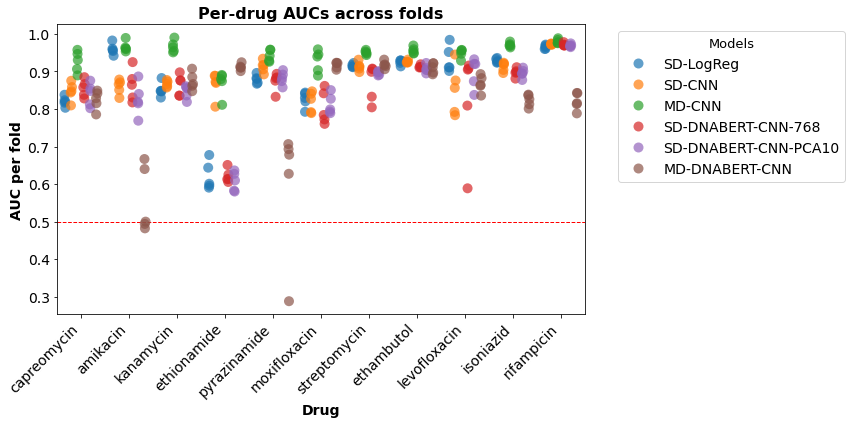

In [4]:
# === Convert to DataFrame ===
records = []
for drug, models in fold_data.items():
    for model, aucs in models.items():
        for auc in aucs:
            records.append({"drug": drug, "model": model, "auc": auc})

df_plot = pd.DataFrame(records)

# --- order drugs (optional: by mean AUC) ---
drug_order = list(fold_data.keys())

plt.figure(figsize=(12,6))
sns.stripplot(
    data=df_plot,    # <---- use filtered dataframe here
    x="drug", y="auc", hue="model",
    order=drug_order, dodge=True, jitter=True, alpha=0.7,size=10
)

# baseline at random guess
plt.axhline(0.5, color="red", linestyle="--", lw=1)

# labels and formatting
plt.xticks(rotation=45, ha="right", fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Drug", fontsize=14, weight="bold")
plt.ylabel("AUC per fold", fontsize=14, weight="bold")
plt.title("Per-drug AUCs across folds", fontsize=16, weight="bold")
plt.legend(
    title="Models",
    bbox_to_anchor=(1.05, 1), loc="upper left",
    fontsize=14,          # label text size
    title_fontsize=13     # legend title size
)
plt.tight_layout()
# plt.savefig("data/latest/cross_val/combined/per_drug_aucs_no_lasso_ridge.png", dpi=300)
plt.savefig("figures/per_drug_auc.png", dpi=300)
plt.show()

## Plot for ΔAUC between foundation model embedding variants vs sequence mean variant

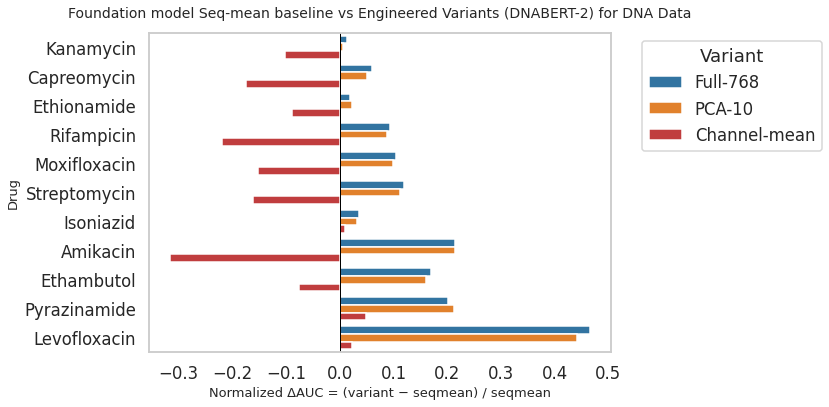

In [ ]:
# ============================================================
# Step 1. Define the ΔAUC DataFrame
# ============================================================

wide = pd.DataFrame({
    "Drug": [
        "Amikacin",
        "Capreomycin",
        "Ethambutol",
        "Ethionamide",
        "Isoniazid",
        "Kanamycin",
        "Levofloxacin",
        "Moxifloxacin",
        "Pyrazinamide",
        "Rifampicin",
        "Streptomycin"
    ],
    "ndelta_pca10": [0.214, 0.051, 0.161, 0.022, 0.032, 0.005, 0.442, .098, 0.212, 0.087, 0.112],
    "ndelta_dnabert768": [0.215, 0.059, 0.169, 0.018, 0.035, 0.014, 0.465, 0.105, 0.202, 0.093, 0.119],
    "ndelta_channelmean": [
    -0.317,  # Amikacin
    -0.175,  
    -0.077, 
    -0.089,  
    0.009,  
    -0.102,  
    0.023,  
    -0.152, 
    0.048,  
    -.219,  
    -0.162   
]        
})

# ============================================================
# Step 2. Variants and pretty names (for legend)
# ============================================================

variants_plot = ["dnabert768", "pca10", "meanseq", "channelmean"]
pretty_names = {
    "pca10": "PCA-10",
    "dnabert768": "Full-768",
    # "meanseq": "Seq-mean",
    "channelmean": "Channel-mean"
}

# ============================================================
# Step 3. Convert to tidy DataFrame for plotting
# ============================================================

records = []
for _, row in wide.iterrows():
    drug = row["Drug"]
    for v in variants_plot:
        val = row.get(f"ndelta_{v}", None)
        if pd.notna(val):
            records.append({
                "Drug": drug,
                "Variant": pretty_names[v],
                "ΔAUC": val
            })

plot_df = pd.DataFrame(records)

# Sort drugs for readability (by mean ΔAUC)
drug_order = plot_df.groupby("Drug")["ΔAUC"].mean().sort_values().index

# ============================================================
# Step 4. Plot styling (matches protein model figure)
# ============================================================

sns.set(style="whitegrid", context="talk", font_scale=1.0)
plt.figure(figsize=(12, 6))

palette = {
    "Full-768": "#1f77b4",
    "PCA-10": "#ff7f0e",
    "Channel-mean": "#d62728"
}

sns.barplot(
    data=plot_df,
    x="ΔAUC",
    y="Drug",
    hue="Variant",
    order=drug_order,
    orient="h",
    palette=palette
)

# Reference line at ΔAUC = 0
plt.axvline(0, color="black", linewidth=1)

# Remove all background gridlines (both horizontal & vertical)
ax = plt.gca()
ax.grid(False)

# ============================================================
# Step 5. Titles, labels, legend
# ============================================================

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Normalized ΔAUC = (variant − seqmean) / seqmean", fontsize=13)
plt.ylabel("Drug", fontsize=13)
plt.title(
    "Foundation model Seq-mean baseline vs Engineered Variants (DNABERT-2) for DNA Data",
    fontsize=14, pad=15
)
plt.legend(title="Variant", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

# ============================================================
# Step 6. Save or display
# ============================================================
plt.savefig("dnabert_variants_vs_seqmean_grouped.pdf")
# plt.savefig("dnabert_variants_vs_seqmean_grouped.png", dpi=300)
plt.show()
plt.close()


## Plot for heatmap generation for the ΔAUC values above

/tmp/ipykernel_3865330/1174476739.py:40: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = heatmap_df.applymap(lambda x: f"{x:.1f}%" if pd.notnull(x) else "")


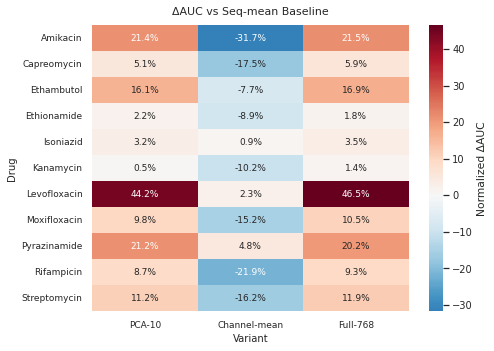

In [ ]:
# === 1. Data (ΔAUC values in fraction form) ===
df = pd.DataFrame({
    "Drug": [
        "Amikacin",
        "Capreomycin",
        "Ethambutol",
        "Ethionamide",
        "Isoniazid",
        "Kanamycin",
        "Levofloxacin",
        "Moxifloxacin",
        "Pyrazinamide",
        "Rifampicin",
        "Streptomycin"
    ],
    "PCA-10":  [0.214, 0.051, 0.161, 0.022, 0.032, 0.005, 0.442, .098, 0.212, 0.087, 0.112],
    "Channel-mean": [
    -0.317,  # Amikacin
    -0.175,  
    -0.077, 
    -0.089,  
    0.009,  
    -0.102,  
    0.023,  
    -0.152, 
    0.048,  
    -.219,  
    -0.162   
],
    "Full-768": [0.215, 0.059, 0.169, 0.018, 0.035, 0.014, 0.465, 0.105, 0.202, 0.093, 0.119]
})

# === 2. Convert to percentage ===
heatmap_df = df.set_index("Drug")[["PCA-10", "Channel-mean", "Full-768"]] * 100
annot_labels = heatmap_df.applymap(lambda x: f"{x:.1f}%" if pd.notnull(x) else "")

# === 3. Plot ===
plt.figure(figsize=(7, 5))
sns.set(style="white", context="notebook", font_scale=0.9)

ax = sns.heatmap(
    heatmap_df,
    annot=annot_labels,
    fmt="",  # already formatted
    cmap="RdBu_r",
    center=0,
    linewidths=0,  # remove gaps between boxes
    linecolor=None,
    cbar_kws={"label": "Normalized ΔAUC"},
    annot_kws={"fontsize": 9}
)

# === 4. Clean formatting ===
plt.title("ΔAUC vs Seq-mean Baseline", fontsize=11, pad=10)
plt.xlabel("Variant", fontsize=10)
plt.ylabel("Drug", fontsize=10)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()

# === 5. Save outputs ===
out_dir = Path("./figures")
out_dir.mkdir(exist_ok=True)
plt.savefig(out_dir / "sd_dnabert_heatmap.pdf", bbox_inches="tight")

plt.show()
plt.close()
